# Figure 4: Multiple occluders

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
cd "/app/"

/app


/usr/local/lib/python3.9/dist-packages/IPython/core/magics/osm.py:417: UserWarning: using dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


In [3]:
%run env_aws.py
%run run.py connect

2025-07-02 08:07:53,825::INFO::settings.py::Setting loglevel to INFO
2025-07-02 08:07:53,826::INFO::settings.py::Setting stores to {}
2025-07-02 08:07:53,827::INFO::settings.py::Setting database.misc.schema_prefix to 
2025-07-02 08:07:53,827::INFO::settings.py::Setting database.misc.create_tables to True
2025-07-02 08:07:53,829::INFO::settings.py::Setting enable_python_native_blobs to True
2025-07-02 08:07:53,830::INFO::settings.py::Setting database.host to vr4mice-ar-collab.cluster-cn54f38qpzgm.eu-central-1.rds.amazonaws.com
2025-07-02 08:07:53,831::INFO::settings.py::Setting database.user to celia
2025-07-02 08:07:53,832::INFO::settings.py::Setting database.password to celia_mathislab
2025-07-02 08:07:54,012::INFO::connection.py::Connected celia@vr4mice-ar-collab.cluster-cn54f38qpzgm.eu-central-1.rds.amazonaws.com:3306


Connecting celia@vr4mice-ar-collab.cluster-cn54f38qpzgm.eu-central-1.rds.amazonaws.com:3306


2025-07-02 08:07:54,118::INFO::table.py::could not log event in table ~log
2025-07-02 08:07:54,551::INFO::table.py::could not log event in table ~log
2025-07-02 08:07:54,551::INFO::table.py::could not log event in table ~log
2025-07-02 08:07:55,049::INFO::table.py::could not log event in table ~log
2025-07-02 08:07:55,049::INFO::table.py::could not log event in table ~log
2025-07-02 08:07:55,199::INFO::table.py::could not log event in table ~log
2025-07-02 08:07:55,199::INFO::table.py::could not log event in table ~log
2025-07-02 08:07:55,528::INFO::table.py::could not log event in table ~log
2025-07-02 08:07:55,528::INFO::table.py::could not log event in table ~log
2025-07-02 08:07:55,852::INFO::table.py::could not log event in table ~log
2025-07-02 08:07:55,852::INFO::table.py::could not log event in table ~log


In [4]:
from vr4mice.schema.base_analysis import DataFrame
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from vr4mice.analysis import plotting
from base_schemas.schemas.exp import Session
from vr4mice.schema import base_analysis
from vr4mice.analysis.analysis import style
from vr4mice.analysis import analysis
from vr4mice.schema import dlc, vr4mice
from vr4mice.analysis import utils
from vr4mice.schema.vr4mice import Groups, Labels
from vr4mice.schema.session_metrics import TrialMetrics
from vr4mice.schema.interpolated_trajectories import InterpolatedTrials, MeanXYTrajectory, YBinnedXYTrajectory, MeanVelocities
from vr4mice.analysis.analysis import mean_xy_trajectory
from vr4mice.analysis.stats import get_p_values_multi, get_multi_performance_p_val, plot_aperture_heatmap

from statsmodels.stats.anova import AnovaRM
from scipy.stats import ttest_rel, ttest_ind
import scipy.stats as stats

style()

save_fig_path = "notebooks/Paper_figures/Figure_output/"

2025-07-02 08:07:56,133::INFO::table.py::could not log event in table ~log
2025-07-02 08:07:56,133::INFO::table.py::could not log event in table ~log
2025-07-02 08:07:56,252::INFO::table.py::could not log event in table ~log
2025-07-02 08:07:56,252::INFO::table.py::could not log event in table ~log


In [5]:
trial_df = (Groups() * (Labels()  & 'label = "ar_paper"') * (vr4mice.Dataset() & 'session_label = "ar_discrim_5_occluders"') * TrialMetrics()).fetch(as_dict=True)
trial_df = pd.concat([pd.DataFrame(x) for x in trial_df])
trial_df ["aperture"] = trial_df.aperture.round(2)
trial_df, reward_table = utils.multi_occluder_inclusion_criteria(trial_df[["dataset", "aperture", "trial", "trial_left_choice", "trial_rewarded", "trial_tortuosity", "trial_duration"]], threshold_drop=.25, return_excluded=False)
# Create list of included datasets

mouse_list = trial_df.dataset.unique()
trial_df["mouse_name"] = trial_df.dataset.str.split("_").str [0]

Excluded datasets:  ['31726_2025-03-25_1' '31726_2025-03-26_1' '31728_2025-03-10_1'
 '31728_2025-03-12_1' '31728_2025-03-17_1' 'Jacana_2024-08-20_1'
 'Lemming_2024-08-16_1' 'Oribi_2024-08-23_1' 'Oribi_2024-08-28_1'
 'Pheasant_2024-08-23_1' 'Pheasant_2024-08-27_2']


In [7]:
trial_df.mouse_name.nunique(), trial_df.dataset.nunique()

(9, 25)

In [6]:
trial_df.groupby("mouse_name").nunique().dataset

mouse_name
31726          2
31728          2
J729           4
Jacana         2
Kiwi           3
Lemming        3
Nightingale    4
Oribi          3
Pheasant       2
Name: dataset, dtype: int64

In [16]:
trial_df.dataset.unique()

array(['31726_2025-03-27_1', '31726_2025-03-28_1', '31728_2025-03-11_1',
       '31728_2025-03-14_1', 'J729_2024-12-11_1', 'J729_2024-12-12_1',
       'J729_2024-12-13_1', 'J729_2024-12-15_1', 'Jacana_2024-08-21_1',
       'Jacana_2024-08-22_1', 'Kiwi_2024-08-19_1', 'Kiwi_2024-08-20_1',
       'Kiwi_2024-08-21_1', 'Lemming_2024-08-14_1',
       'Lemming_2024-08-15_1', 'Lemming_2024-08-19_1',
       'Nightingale_2024-08-15_1', 'Nightingale_2024-08-16_1',
       'Nightingale_2024-08-21_1', 'Nightingale_2024-08-22_1',
       'Oribi_2024-08-26_1', 'Oribi_2024-08-27_1', 'Oribi_2024-08-29_1',
       'Pheasant_2024-08-26_1', 'Pheasant_2024-08-28_1'], dtype=object)

In [9]:
trial_df["lab_id"] = 0
for dataset_name in mouse_list:
    # Fetch lab_id for each dataset
    trial_df.loc[trial_df.dataset==dataset_name, "lab_id"] = ((vr4mice.Collab() & f'dataset = "{dataset_name}"') * vr4mice.Labs()).fetch("lab")[0]

2025-07-01 11:28:08,249::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-07-01 11:28:08,249::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-07-01 11:28:08,255::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-07-01 11:28:08,255::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-07-01 11:28:08,283::INFO::category.py::Using categorical un

                Anova
         F Value Num DF  Den DF Pr > F
--------------------------------------
aperture  0.0901 4.0000 96.0000 0.9854



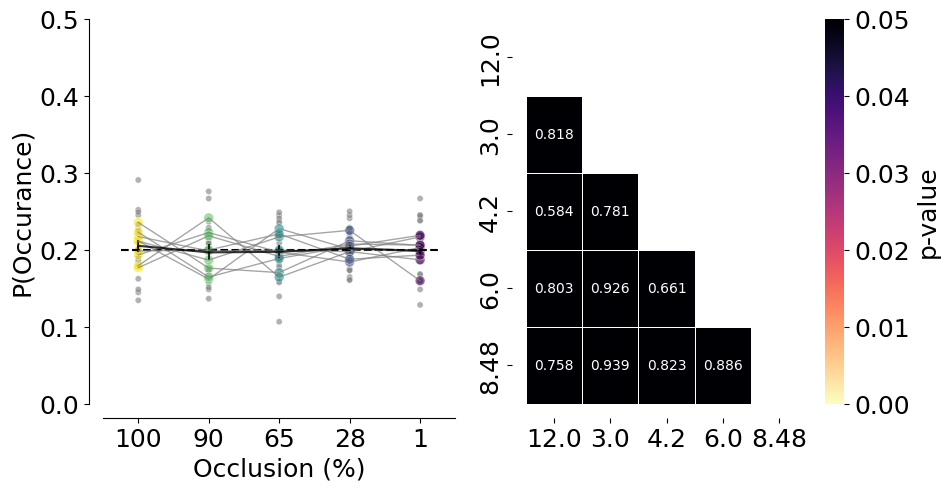

In [7]:
# Occurance of the different conditions
counts = (
    trial_df.groupby(["dataset", "mouse_name", "aperture"])
    .trial.nunique()
    .reset_index(name="trial_count")
)
total_trials = (
    trial_df.groupby("dataset").trial.nunique().reset_index(name="total_trials")
)

counts = counts.merge(total_trials, on="dataset")
counts["probability"] = counts["trial_count"] / counts["total_trials"]
counts.sort_values("aperture", inplace=True)
counts["aperture"] = counts.aperture.astype("str")

fig, ax = plt.subplots(1, 2, figsize=(10, 5))

sns.lineplot(
    data=counts.groupby(["aperture", "mouse_name"], as_index=False).probability.mean(),
    x="aperture",
    y="probability",
    units="mouse_name",
    estimator=None,
    color="grey",
    alpha=0.7,
    linewidth=1,
    zorder=3,
    ax=ax[0]
)

sns.scatterplot(
    data=counts.groupby(["aperture", "mouse_name"], as_index=False).probability.mean(),
    x="aperture",
    y="probability",
    hue="aperture",
    palette=plotting.colors_multi_aperture,
    alpha=0.6,
    s=50,
    zorder=2,
    ax=ax[0]
)

sns.scatterplot(
    data=counts,
    x="aperture",
    y="probability",
    hue="aperture",
    palette=["grey"] * counts["dataset"].nunique(),
    alpha=0.6,
    zorder=1,
    s=20,
    ax=ax[0]
)

sns.lineplot(
    data=counts.groupby(["aperture", "mouse_name"], as_index=False).probability.mean(),
    x="aperture",
    y="probability",
    color="black",
    err_style="bars",
    errorbar="se",
    alpha=0.8,
    zorder=4,
    ax=ax[0]
)

ax[0].hlines(
    0.2,
    xmin=-0.25,
    xmax=len(trial_df.aperture.unique()) - 0.75,
    linestyles="dashed",
    colors="k",
)

ax[0].set_ylim(0, .5)
ax[0].set_xlim(-0.5, 4.5)
ax[0].set_xticks([0, 1, 2, 3, 4], ["100", "90", "65", "28", "1"])

ax[0].set_xlabel("Occlusion (%)")
ax[0].set_ylabel("P(Occurance)")
sns.despine(offset=10)
ax[0].legend([], [], frameon=False)

p_values = get_multi_performance_p_val(counts,  y_var="probability")
plot_aperture_heatmap(p_values, ax= ax[1])
print(AnovaRM(counts, depvar="probability", subject="dataset", within=["aperture"]).fit())

plt.savefig(save_fig_path + "figure4_multi_occluder_trial_number.svg", transparent=True)

In [8]:
print(AnovaRM(counts,
        depvar="probability", subject="dataset", within=["aperture"]).fit())

                Anova
         F Value Num DF  Den DF Pr > F
--------------------------------------
aperture  0.0901 4.0000 96.0000 0.9854



2025-07-01 11:28:08,935::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-07-01 11:28:08,935::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-07-01 11:28:08,943::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-07-01 11:28:08,943::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-07-01 11:28:09,025::INFO::category.py::Using categorical un

3.0-4.2: TtestResult(statistic=-2.0910925580108795, pvalue=0.04728248861079895, df=24)
3.0-6.0: TtestResult(statistic=-4.830965673377193, pvalue=6.38319530380985e-05, df=24)
3.0-8.48: TtestResult(statistic=-5.523879283374772, pvalue=1.1104543950005748e-05, df=24)
4.2-6.0: TtestResult(statistic=-2.199927768181941, pvalue=0.03768255574071594, df=24)
4.2-8.48: TtestResult(statistic=-2.968397820508206, pvalue=0.006688811903391687, df=24)
6.0-8.48: TtestResult(statistic=-0.5058276197992468, pvalue=0.6175922888247101, df=24)
12.0-3.0: TtestResult(statistic=4.7890505894611985, pvalue=7.100502711101454e-05, df=24)
12.0-4.2: TtestResult(statistic=2.2316212656801184, pvalue=0.03523885609626643, df=24)
12.0-6.0: TtestResult(statistic=0.045502649901139954, pvalue=0.9640831640660874, df=24)
12.0-8.48: TtestResult(statistic=-0.6873382392150224, pvalue=0.498458549120927, df=24)
              mean       sem
aperture                    
12.0      0.891895  0.018587
3.0       0.749104  0.021262
4.2     

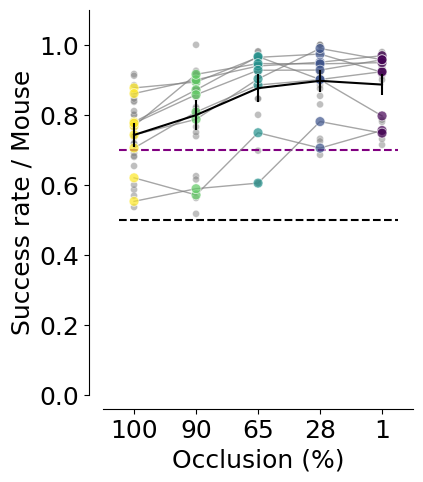

In [9]:
# Success rate per mouse (new)
fig, ax = plt.subplots(1, 1, figsize=(4, 5))
plotting.plot_rate(
    df=trial_df,
    label_x="trial_rewarded",
    per_aperture=True,
    ax=ax,
    cmap=plotting.colors_multi_aperture,
    per_mouse=True,
)
ax.hlines(
    0.7,
    xmin=-0.25,
    xmax=len(trial_df.aperture.unique()) - 0.75,
    linestyles="dashed",
    colors="purple",
)
ax.hlines(
    0.5,
    xmin=-0.25,
    xmax=len(trial_df.aperture.unique()) - 0.75,
    linestyles="dashed",
    colors="k",
)

ax.set_ylim(0, 1.1)
ax.set_xlim(-0.5, 4.5)
ax.set_xlabel("Occlusion (%)")
ax.set_ylabel("Success rate / Mouse")
ax.set_xticks([0, 1, 2, 3, 4], ["100", "90", "65", "28", "1"])

ax.legend([], [], frameon=False)
sns.despine(offset=10)

plt.savefig(save_fig_path + "figure4_multi_occluder_rewards_per_mouse.svg", transparent=True)

2025-07-01 11:28:09,452::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-07-01 11:28:09,452::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-07-01 11:28:09,460::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-07-01 11:28:09,460::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-07-01 11:28:09,541::INFO::category.py::Using categorical un

3.0-4.2: TtestResult(statistic=0.1925974419032768, pvalue=0.848894715097364, df=24)
3.0-6.0: TtestResult(statistic=0.49700503620002023, pvalue=0.6237078798528989, df=24)
3.0-8.48: TtestResult(statistic=-0.17238329726083185, pvalue=0.8645816372097157, df=24)
4.2-6.0: TtestResult(statistic=0.2888401279558972, pvalue=0.7751839047896278, df=24)
4.2-8.48: TtestResult(statistic=-0.4043448169521935, pvalue=0.6895400231562736, df=24)
6.0-8.48: TtestResult(statistic=-0.8382579133954651, pvalue=0.41015706557167175, df=24)
12.0-3.0: TtestResult(statistic=0.8514243859080306, pvalue=0.40294944079398054, df=24)
12.0-4.2: TtestResult(statistic=1.2027829152788376, pvalue=0.2407923890386427, df=24)
12.0-6.0: TtestResult(statistic=2.1357397142861156, pvalue=0.04310636743370375, df=24)
12.0-8.48: TtestResult(statistic=1.1163127113477662, pvalue=0.2753405213938939, df=24)
              mean       sem
aperture                    
12.0      0.524549  0.016929
3.0       0.492552  0.028828
4.2       0.485451 

2025-07-01 11:28:09,830::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-07-01 11:28:09,835::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-07-01 11:28:09,835::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-07-01 11:28:09,850::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-07-01 11:28:09,850::INFO::category.py::Using categorical un

3.0-4.2: TtestResult(statistic=0.3303329546903208, pvalue=0.7440147221911171, df=24)
3.0-6.0: TtestResult(statistic=0.5474973379875565, pvalue=0.5890929385696668, df=24)
3.0-8.48: TtestResult(statistic=-0.28162984226312127, pvalue=0.7806414478763297, df=24)
4.2-6.0: TtestResult(statistic=0.33326551431673085, pvalue=0.7418278714668143, df=24)
4.2-8.48: TtestResult(statistic=-0.6351285779922629, pvalue=0.5313537966029576, df=24)
6.0-8.48: TtestResult(statistic=-1.08954063479577, pvalue=0.28673501955019925, df=24)
12.0-3.0: TtestResult(statistic=1.4802509019087695, pvalue=0.15181514125284346, df=24)
12.0-4.2: TtestResult(statistic=1.8501849075249917, pvalue=0.07663684708004127, df=24)
12.0-6.0: TtestResult(statistic=2.5416645549429004, pvalue=0.017907792162877075, df=24)
12.0-8.48: TtestResult(statistic=1.279571292169318, pvalue=0.2129281449325434, df=24)
              mean       sem
aperture                    
12.0      0.524549  0.016929
3.0       0.492552  0.028828
4.2       0.485451 

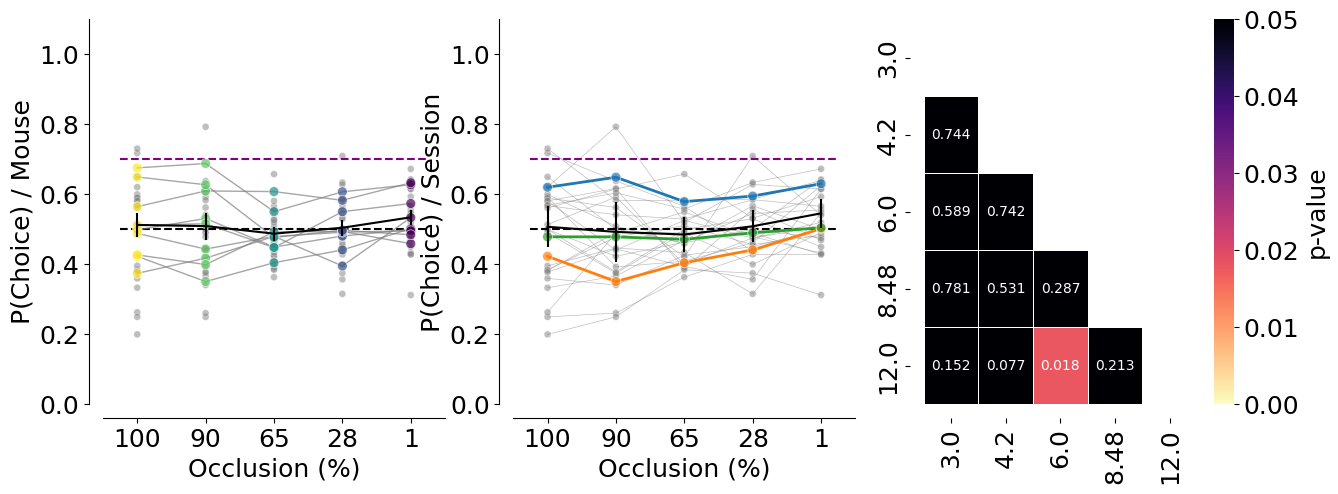

In [10]:
# Success rate per mouse (new)
fig, ax = plt.subplots(1, 3, figsize=(15, 5))
plotting.plot_rate(
    df=trial_df,
    label_x="trial_left_choice",
    per_aperture=True,
    ax=ax[0],
    cmap=plotting.colors_multi_aperture,
    per_mouse=True,
)
ax[0].hlines(
    0.7,
    xmin=-0.25,
    xmax=len(trial_df.aperture.unique()) - 0.75,
    linestyles="dashed",
    colors="purple",
)
ax[0].hlines(
    0.5,
    xmin=-0.25,
    xmax=len(trial_df.aperture.unique()) - 0.75,
    linestyles="dashed",
    colors="k",
)

ax[0].set_ylim(0, 1.1)
ax[0].set_xlim(-0.5, 4.5)
ax[0].set_xlabel("Occlusion (%)")
ax[0].set_ylabel("P(Choice) / Mouse")
ax[0].set_xticks([0, 1, 2, 3, 4], ["100", "90", "65", "28", "1"])

ax[0].legend([], [], frameon=False)
sns.despine(offset=10)

plotting.plot_rate(
    df=trial_df,
    label_x="trial_left_choice",
    per_aperture=True,
    ax=ax[1],
    cmap=plotting.colors_multi_aperture,
    per_lab=True,
)
ax[1].hlines(
    0.7,
    xmin=-0.25,
    xmax=len(trial_df.aperture.unique()) - 0.75,
    linestyles="dashed",
    colors="purple",
)
ax[1].hlines(
    0.5,
    xmin=-0.25,
    xmax=len(trial_df.aperture.unique()) - 0.75,
    linestyles="dashed",
    colors="k",
)

ax[1].set_ylim(0, 1.1)
ax[1].set_xlim(-0.5, 4.5)
ax[1].set_xlabel("Occlusion (%)")
ax[1].set_ylabel("P(Choice) / Session")
ax[1].set_xticks([0, 1, 2, 3, 4], ["100", "90", "65", "28", "1"])

ax[1].legend([], [], frameon=False)
sns.despine(offset=10)

p_values = get_multi_performance_p_val(trial_df,  y_var="trial_left_choice")
plot_aperture_heatmap(p_values, ax=ax[2])
mean_mouse = trial_df.groupby(["dataset", "aperture"], as_index=False).mean()
print(AnovaRM(mean_mouse, depvar="trial_left_choice", subject="dataset", within=["aperture"]).fit())

plt.savefig(save_fig_path + "figure4_multi_occluder_choice_bias.svg", transparent=True)

2025-07-01 11:28:10,689::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-07-01 11:28:10,689::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-07-01 11:28:10,704::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-07-01 11:28:10,704::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-07-01 11:28:10,751::INFO::category.py::Using categorical un

2025-07-01 11:28:10,757::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-07-01 11:28:10,848::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-07-01 11:28:10,848::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-07-01 11:28:10,853::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-07-01 11:28:10,853::INFO::category.py::Using categorical un

3.0-4.2: TtestResult(statistic=-4.294775142156709, pvalue=0.000249592248485294, df=24)
3.0-6.0: TtestResult(statistic=-8.63596674410741, pvalue=7.938488027221137e-09, df=24)
3.0-8.48: TtestResult(statistic=-9.922891044401927, pvalue=5.716543717984163e-10, df=24)
4.2-6.0: TtestResult(statistic=-4.96095944839423, pvalue=4.5893003535062247e-05, df=24)
4.2-8.48: TtestResult(statistic=-5.653014738081343, pvalue=8.04406204065893e-06, df=24)
6.0-8.48: TtestResult(statistic=-0.9143341342926102, pvalue=0.36963645105671183, df=24)
12.0-3.0: TtestResult(statistic=9.908373156320879, pvalue=5.88184256287188e-10, df=24)
12.0-4.2: TtestResult(statistic=4.653696076204195, pvalue=0.00010017441571757577, df=24)
12.0-6.0: TtestResult(statistic=0.07659887976618203, pvalue=0.9395776368965353, df=24)
12.0-8.48: TtestResult(statistic=-0.931285761959232, pvalue=0.36097991128194373, df=24)
              mean       sem
aperture                    
12.0      0.891895  0.018587
3.0       0.749104  0.021262
4.2   

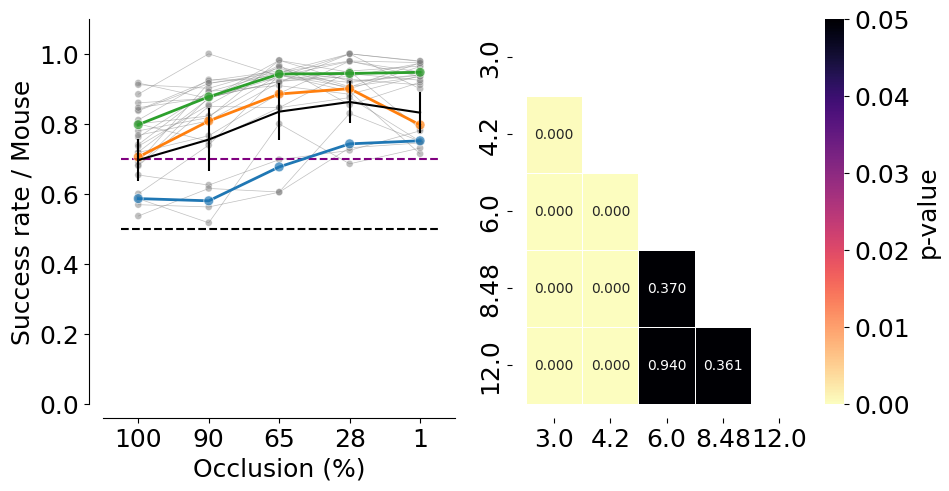

In [11]:
# Success rate per mouse (new)
fig, ax = plt.subplots(1, 2, figsize=(10, 5))
plotting.plot_rate(
    df=trial_df,
    label_x="trial_rewarded",
    per_aperture=True,
    ax=ax[0],
    cmap=plotting.colors_multi_aperture,
    per_lab=True,
)
ax[0].hlines(
    0.7,
    xmin=-0.25,
    xmax=len(trial_df.aperture.unique()) - 0.75,
    linestyles="dashed",
    colors="purple",
)
ax[0].hlines(
    0.5,
    xmin=-0.25,
    xmax=len(trial_df.aperture.unique()) - 0.75,
    linestyles="dashed",
    colors="k",
)

ax[0].set_ylim(0, 1.1)
ax[0].set_xlim(-0.5, 4.5)
ax[0].set_xlabel("Occlusion (%)")
ax[0].set_ylabel("Success rate / Mouse")
ax[0].set_xticks([0, 1, 2, 3, 4], ["100", "90", "65", "28", "1"])

ax[0].legend([], [], frameon=False)
sns.despine(offset=10)

p_values = get_multi_performance_p_val(trial_df,  y_var="trial_rewarded")
plot_aperture_heatmap(p_values, ax=ax[1])
mean_mouse = trial_df.groupby(["dataset", "aperture"], as_index=False).mean()
print(AnovaRM(mean_mouse, depvar="trial_rewarded", subject="dataset", within=["aperture"]).fit())

plt.savefig(save_fig_path + "figure4_multi_occluder_rewards.svg", transparent=True)

2025-07-01 12:14:45,260::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-07-01 12:14:45,260::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-07-01 12:14:45,266::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-07-01 12:14:45,266::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-07-01 12:14:45,307::INFO::category.py::Using categorical un

                Anova
         F Value Num DF  Den DF Pr > F
--------------------------------------
aperture 11.8531 4.0000 96.0000 0.0000



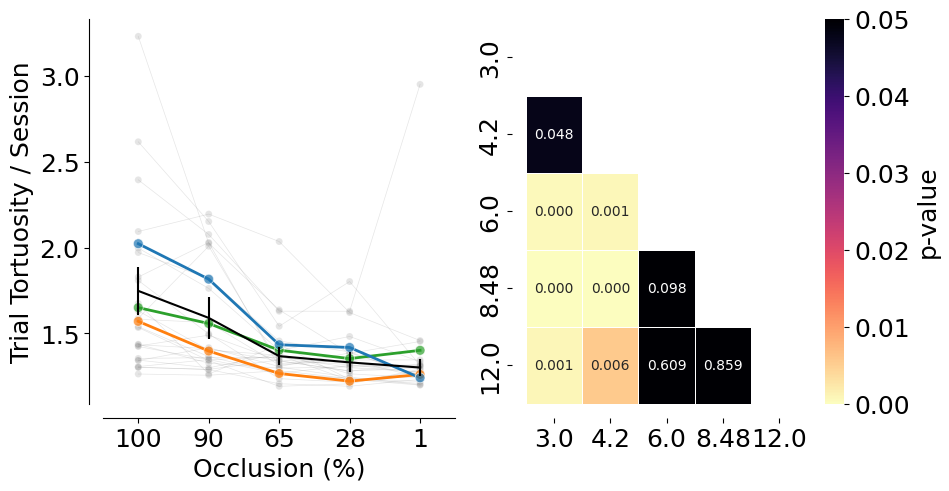

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(10, 5))

counts = (
    trial_df
    .groupby(["lab_id", "dataset", "aperture"], as_index=False)
    .trial_tortuosity.mean()
)

counts["count"] = counts["trial_tortuosity"]
counts = pd.DataFrame(counts.reset_index())
counts.aperture = counts.aperture.round(2).astype(str)

plotting._plot_bar_counts(
    counts=counts,
    label_x="aperture",
    alpha=0.2,
    ax=ax[0],
    per_lab=True,
    cmap=plotting.colors_aperture[0:2],
)
ax[0].invert_xaxis()

ax[0].set_xlim(-0.5, 4.5)
ax[0].set_xlabel("Occlusion (%)")
ax[0].set_ylabel("Trial Tortuosity / Session")
ax[0].set_xticks([0, 1, 2, 3, 4], ["100", "90", "65", "28", "1"])

ax[0].legend([], [], frameon=False)
sns.despine(offset=10)

p_values = get_multi_performance_p_val(trial_df,  y_var="trial_tortuosity")
plot_aperture_heatmap(p_values, ax=ax[1])
mean_mouse = trial_df.groupby(["dataset", "aperture"], as_index=False).mean()
print(AnovaRM(mean_mouse, depvar="trial_tortuosity", subject="dataset", within=["aperture"]).fit())

plt.savefig(save_fig_path + "figure4_multi_occluder_tortuosity.svg", transparent=True)

# Trajectory analysis

In [12]:
# This takes a while to fetch because we need to fetch data for all trials (4 min 20 secs) 
dataset_list = []
for d in mouse_list:    
    print(d)
    try:
        if len(MeanXYTrajectory() & f'dataset = "{d}"') > 0:
            dataset_list.append(pd.DataFrame((MeanXYTrajectory() & f'dataset = "{d}"').fetch(as_dict=True)[0]))
        else:
            print("dataset missing")
    except Exception as err:
        print(err, " dataset missing")
interpolated_df = pd.concat(dataset_list)
interpolated_df ["mouse_name"] = interpolated_df.dataset.str.split("_").str [0]

31726_2025-03-27_1
31726_2025-03-28_1
31728_2025-03-11_1
31728_2025-03-14_1
J729_2024-12-11_1
J729_2024-12-12_1
J729_2024-12-13_1
J729_2024-12-15_1
Jacana_2024-08-21_1
Jacana_2024-08-22_1
Kiwi_2024-08-19_1
Kiwi_2024-08-20_1
Kiwi_2024-08-21_1
Lemming_2024-08-14_1
Lemming_2024-08-15_1
Lemming_2024-08-19_1
Nightingale_2024-08-15_1
Nightingale_2024-08-16_1
Nightingale_2024-08-21_1
Nightingale_2024-08-22_1
Oribi_2024-08-26_1
Oribi_2024-08-27_1
Oribi_2024-08-29_1
Pheasant_2024-08-26_1
Pheasant_2024-08-28_1


In [13]:
mean_xy = mean_xy_trajectory(interpolated_df, index_columns=["aperture", "trial_left_choice", "trial_length"])

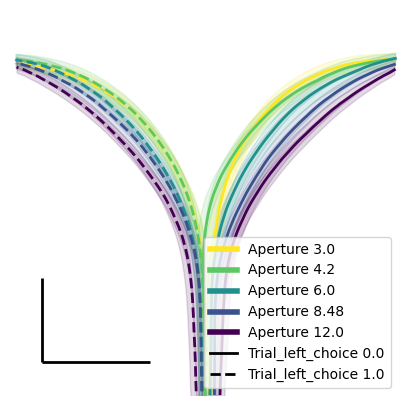

In [14]:
plotting.plot_mean_xy_trajectory(mean_xy, cmap=plt.cm.viridis_r, color_by="aperture", style_by="choice")
plt.savefig(save_fig_path + "multioccluder_trajectories_time.svg", transparent=True)

In [15]:
mean_mouse_xy = mean_xy_trajectory(interpolated_df, index_columns=["aperture", "mouse_name" ,"trial_left_choice", "trial_length"])

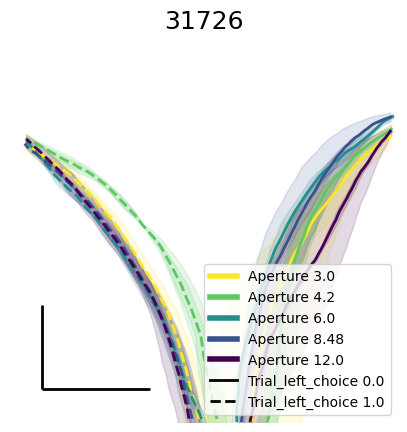

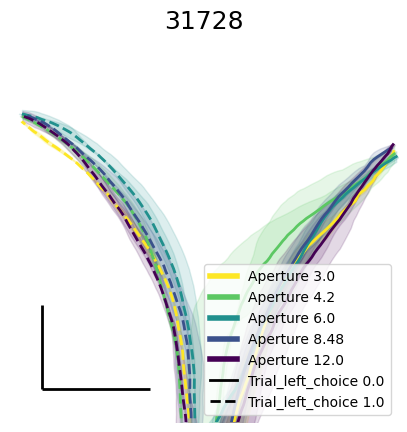

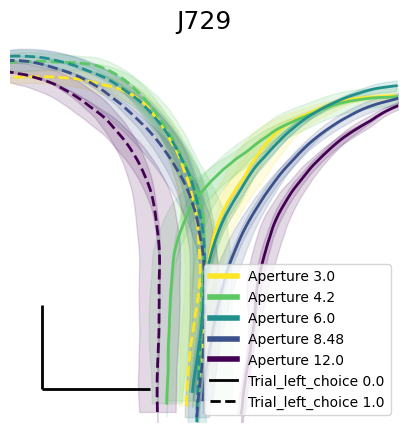

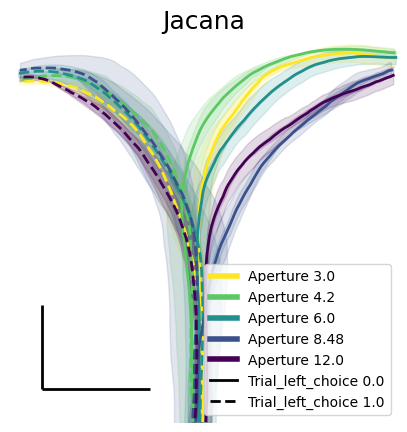

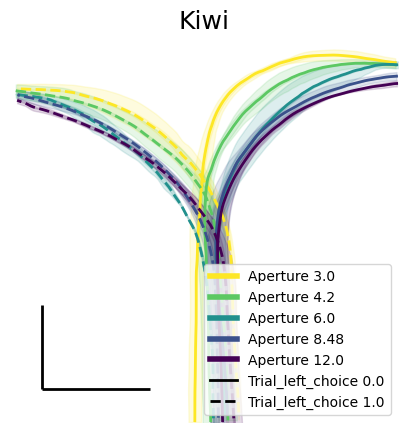

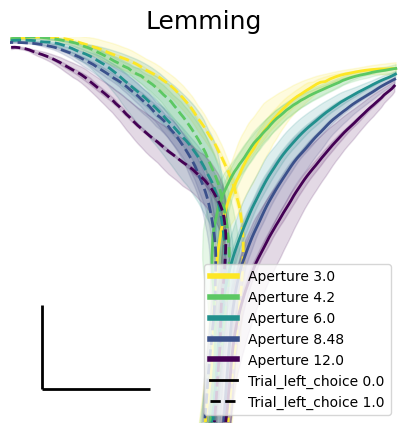

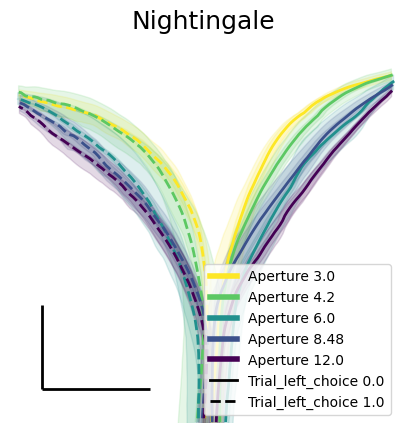

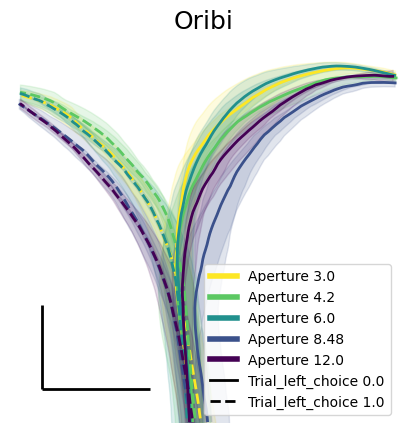

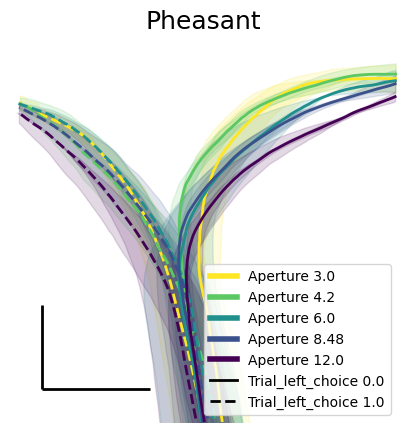

In [16]:
for m in mean_mouse_xy.mouse_name.unique():
    plotting.plot_mean_xy_trajectory(mean_mouse_xy[mean_mouse_xy.mouse_name == m], cmap=plt.cm.viridis_r, color_by="aperture", style_by="choice")
    plt.title(m)
    plt.savefig(save_fig_path + f"multioccluder_trajectories_time_{m}.svg", transparent=True)

# Stats on trajectories

In [17]:
# takes 2 min to fetch
inter_df = []
for m in mouse_list:
    try:
        #print(m)
        inter_df.append(pd.DataFrame((InterpolatedTrials() & f'dataset="{m}"').fetch("dataset", "aperture", "trial", "trial_left_choice", "x", "y", "flip_one_side", "trial_rewarded", "velocity", "trial_length", as_dict=True)[0]))
    except Exception as err:
        print(err)
inter_df = pd.concat(inter_df)

aperture_to_occlusion = {
    12.0: 100,
    8.48: 90,
    6.0: 65,
    4.2: 28,
    3.0: 1
}

# Map the values
inter_df ['aperture'] = inter_df['aperture'].map(aperture_to_occlusion)


inter_df ["mouse_name"] = inter_df.dataset.str.split("_").str [0]
inter_df ["x_flipped"] = inter_df.x * inter_df.flip_one_side
data = utils.create_bins(inter_df [inter_df.trial_rewarded == 1.0].copy())

mean_mouse = (
    data.groupby(
        ["dataset", "trial_left_choice", "aperture", "bin_centers", "trial"],
        as_index=False,
    )
    .mean(numeric_only=True)
    .copy()
)

mean_mouse = (
    mean_mouse.groupby(["dataset", "aperture", "bin_centers"], as_index=False)
    .mean(numeric_only=True)
    .copy()
)

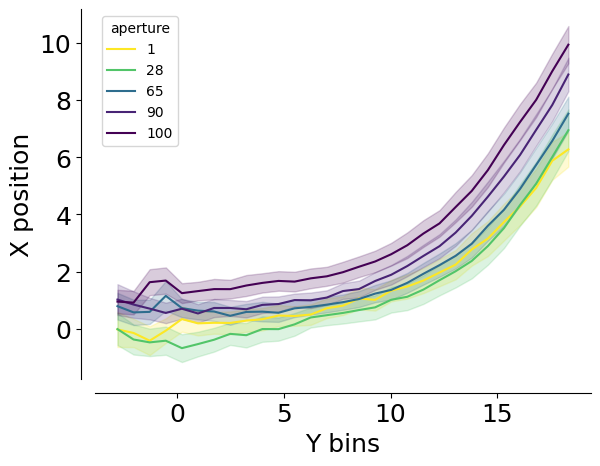

In [18]:
stats_df = mean_mouse[(mean_mouse.bin_centers > -3) & (mean_mouse.bin_centers < 19)]
sns.lineplot(data = stats_df, x="bin_centers", y="x_flipped", hue="aperture", palette= "viridis_r",errorbar="se")
plt.xlabel("Y bins")
plt.ylabel("X position")
sns.despine(offset=10)
plt.savefig(save_fig_path + "figure_4_multioccluder_x_pos.svg")

In [19]:
print(
    AnovaRM(
        data=stats_df,
        depvar="x_flipped",
        subject="dataset",
        within=["aperture", "bin_centers"],
    ).fit()
)

                         Anova
                     F Value   Num DF    Den DF  Pr > F
-------------------------------------------------------
aperture               8.0835   4.0000   96.0000 0.0000
bin_centers          112.8314  28.0000  672.0000 0.0000
aperture:bin_centers   3.4522 112.0000 2688.0000 0.0000



In [20]:
p_value_df = get_p_values_multi(stats_df, x_var="bin_centers", y_var="x_flipped")

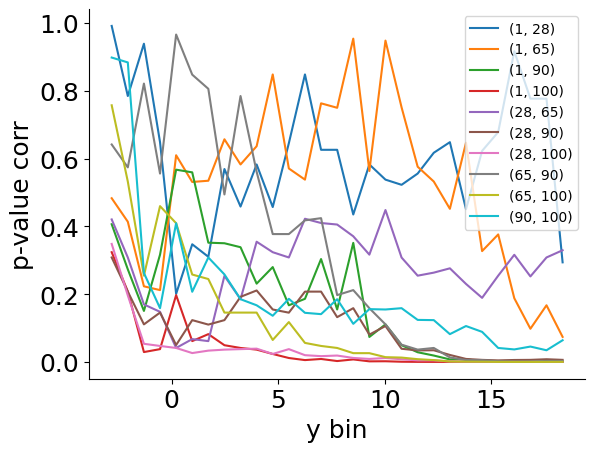

In [21]:
sns.lineplot(data = p_value_df, x="bin", y="p_value_corr", hue=zip(p_value_df.aperture1, p_value_df.aperture2))
plt.ylabel("p-value corr")
plt.xlabel("y bin")
plt.savefig(save_fig_path + "figure_4_multioccluder_pos_pvalue.svg", transparent=True)

In [22]:
p_value_df.pivot(index = "bin", columns=["aperture1", "aperture2"], values=["p_value_corr"])

p_value_corr                                                        \
aperture1           1                                           28             
aperture2          28        65        90            100       65        90    
bin                                                                            
-2.8065       0.991247  0.482906  0.406231  3.237065e-01  0.420379  0.308160   
-2.0510       0.784462  0.413580  0.273180  2.078158e-01  0.308160  0.207402   
-1.2955       0.938739  0.223043  0.150450  2.908923e-02  0.169621  0.110796   
-0.5405       0.648299  0.211862  0.316378  3.772452e-02  0.147768  0.145532   
 0.2145       0.200744  0.609715  0.567149  1.970856e-01  0.041169  0.049873   
 0.9695       0.347025  0.530911  0.559237  6.141310e-02  0.067326  0.123293   
 1.7245       0.310151  0.534536  0.351757  8.197420e-02  0.061363  0.110132   
 2.4795       0.569077  0.656833  0.350096  4.927738e-02  0.253754  0.123293   
 3.2345       0.458359  0.582518  0.338382  4.116897e-02  0.185044  0.192026   
 3.9895       0.582518  0.636369  0.230936  3.628040e-02  0.354583  0.210801   
 4.7445       0.456924  0.848121  0.279801  2.343760e-02  0.323707  0.154692   
 5.5000       0.645255  0.570685  0.167072  1.154184e-02  0.308160  0.145297   
 6.2555       0.848121  0.537779  0.186136  5.406302e-03  0.422375  0.207402   
 7.0105       0.625795  0.762906  0.303485  8.698676e-03  0.409802  0.207402   
 7.7655       0.625795  0.749726  0.154707  2.574764e-03  0.405293  0.132068   
 8.5205       0.434953  0.953778  0.351238  7.372923e-03  0.370689  0.158554   
 9.2755       0.582518  0.563237  0.073653  1.702925e-03  0.316472  0.080552   
 10.0305      0.537779  0.947968  0.110796  1.969001e-03  0.448077  0.105877   
 10.7855      0.522490  0.751048  0.049277  5.542437e-04  0.307917  0.038791   
 11.5405      0.555697  0.575874  0.028539  1.384075e-04  0.254446  0.033963   
 12.2955      0.617013  0.532195  0.018816  7.110094e-05  0.263391  0.034421   
 13.0510      0.648299  0.451684  0.007393  5.453335e-05  0.276115  0.020594   
 13.8065      0.450600  0.646704  0.007921  4.022956e-05  0.230094  0.008796   
 14.5615      0.622551  0.326947  0.001320  7.027763e-06  0.189004  0.006035   
 15.3165      0.678007  0.376102  0.000761  1.590392e-06  0.254446  0.004525   
 16.0715      0.916658  0.187854  0.000095  3.844270e-07  0.316064  0.005699   
 16.8265      0.776791  0.097875  0.000042  2.996033e-07  0.252232  0.006063   
 17.5815      0.776554  0.167072  0.000228  2.158516e-07  0.308160  0.007921   
 18.3365      0.293767  0.073835  0.000349  1.406983e-06  0.329477  0.006087   

                                                   
aperture1                  65                  90  
aperture2       100       90        100       100  
bin                                                
-2.8065    0.348106  0.641499  0.757126  0.897931  
-2.0510    0.196231  0.573962  0.532195  0.883606  
-1.2955    0.053485  0.821208  0.254446  0.262327  
-0.5405    0.047118  0.555697  0.459583  0.158554  
 0.2145    0.041169  0.965795  0.409242  0.409242  
 0.9695    0.026134  0.847484  0.257820  0.206988  
 1.7245    0.033311  0.805703  0.244548  0.308160  
 2.4795    0.036280  0.494100  0.145532  0.258115  
 3.2345    0.037725  0.784462  0.145532  0.185044  
 3.9895    0.039146  0.560874  0.145532  0.167072  
 4.7445    0.023438  0.377184  0.064814  0.136188  
 5.5000    0.037725  0.377184  0.117540  0.186174  
 6.2555    0.019865  0.417615  0.056101  0.144871  
 7.0105    0.017031  0.424107  0.047118  0.140953  
 7.7655    0.018816  0.197127  0.041169  0.185044  
 8.5205    0.011730  0.211862  0.025853  0.112372  
 9.2755    0.008796  0.158476  0.025845  0.155703  
 10.0305   0.011542  0.110796  0.014046  0.154692  
 10.7855   0.007921  0.050860  0.012827  0.158554  
 11.5405   0.004603  0.036280  0.008064  0.123978  
 12.2955   0.004635  0.041169  0.005406  0.123293  
 13.0510   0.001593  0.013244  0.001320  0.081974  
 13.8065   0.0006

# Velocity analysis

In [23]:
velocity_df = []
for m in mouse_list:
    #print(m)
    velocity_df.append(pd.DataFrame((MeanVelocities() & f'dataset="{m}"').fetch(as_dict=True)[0]))
velocity_df = pd.concat(velocity_df)

mean_mouse = velocity_df.groupby(["dataset", "aperture", "trial_length"],as_index=False).mean()

Text(0, 0.5, 'Combined velocity (cm/s)')

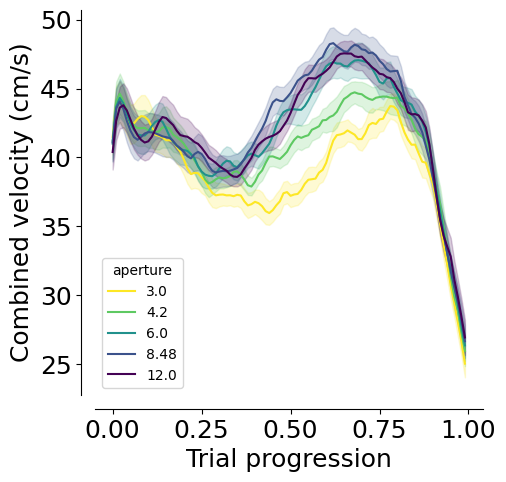

In [24]:
fig, ax = plt.subplots(1, 1, figsize=(5, 5))
sns.lineplot(
    data=mean_mouse,
    x="trial_length",
    y="velocity",
    palette=plotting.colors_multi_aperture,
    hue="aperture",
    errorbar="se",
    ax=ax,
)

sns.despine(offset=10)
ax.set_xlabel("Trial progression")
ax.set_ylabel("Combined velocity (cm/s)")

In [25]:
p_value_df = get_p_values_multi(mean_mouse, x_var="trial_length", y_var="velocity")

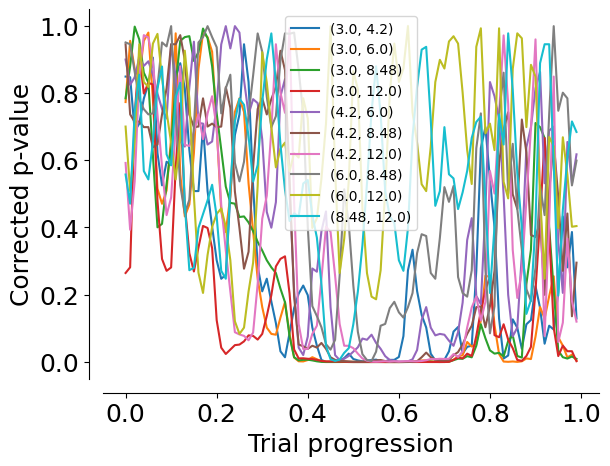

In [26]:
sns.lineplot(data = p_value_df, x="bin", y="p_value_corr", hue=zip(p_value_df.aperture1, p_value_df.aperture2))
plt.ylabel("Corrected p-value")
plt.xlabel("Trial progression")

sns.despine(offset=10)
plt.savefig(save_fig_path + "figure_4_multioccluder_velocity_pvalue.svg", transparent=True)